In [13]:
using JuMP
using Gurobi
using Random
using Dualization
using Plots
using DataFrames
using CSV
import XLSX
import JSON

current_directory = @__DIR__
functions_directory = joinpath(current_directory, "functions")
data_dir = joinpath(current_directory, "data")
results_dir = joinpath(current_directory, "results")

# Include all the function files
# include(joinpath(functions_directory, "create_check_params.jl"))
# include(joinpath(functions_directory, "deterministic_equivalent.jl"))
# include(joinpath(functions_directory, "generate_cuts_from_dual.jl"))
include(joinpath(functions_directory, "load_model_starting_points.jl"))
# include(joinpath(functions_directory, "load_model_starting_points_OLD.jl"))
include(joinpath(functions_directory, "initialize_parameters.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected_with_MVP.jl"))
include(joinpath(functions_directory, "process_scenario_data_n_selected.jl"))
# include(joinpath(functions_directory, "save_L_shaped_results.jl"))
include(joinpath(functions_directory, "select_random_scenarios.jl"))
include(joinpath(functions_directory, "create_vaccine_data.jl"))
# include(joinpath(functions_directory, "sub_problem.jl"))
# include(joinpath(functions_directory, "master_problem.jl"))
include(joinpath(functions_directory, "create_vaccine_data_MMR_only.jl"))

create_vaccine_data_MMR_only (generic function with 1 method)

In [3]:
A, V, A_v, P, P_v, V_a, V_p, P_a, A_p, capacity_category, vaccine_category, antigen_category = create_vaccine_data_MMR_only()

(["Measles", "Mumps", "Rubella"], ["M", "MR", "MMR"], Dict("MMR" => ["Measles", "Mumps", "Rubella"], "MR" => ["Measles", "Rubella"], "M" => ["Measles"]), ["Biological_E", "GSK", "PT_Bio", "Serum_Institute"], Dict("MMR" => ["Serum_Institute", "GSK"], "MR" => ["Serum_Institute", "Biological_E"], "M" => ["Serum_Institute", "PT_Bio"]), Dict("Measles" => ["MMR", "MR", "M"], "Mumps" => ["MMR"], "Rubella" => ["MMR", "MR"]), Dict("Serum_Institute" => ["MMR", "MR", "M"], "Biological_E" => ["MR"], "GSK" => ["MMR"], "PT_Bio" => ["M"]), Dict("Measles" => ["Serum_Institute", "GSK", "Biological_E", "PT_Bio"], "Mumps" => ["Serum_Institute", "GSK"], "Rubella" => ["Serum_Institute", "GSK", "Biological_E"]), Dict("Serum_Institute" => ["Measles", "Mumps", "Rubella"], "Biological_E" => ["Measles", "Rubella"], "GSK" => ["Measles", "Mumps", "Rubella"], "PT_Bio" => ["Measles"]), Dict("Medium" => ["Sanofi", "Pfizer", "Haffkine_Bio", "Bharat_Biotech", "Merck_Sharp", "PT_Bio", "LG_Chem", "BB_NCIPD"], "Small" =>

In [ ]:
starting_points_vect_F, starting_points_vect_I, starting_points_vect_S = load_model_starting_points(data_dir, 1, 1000, A, V)

In [5]:
T, T_initial, Δ, s_real, r, r_avg, r_producer_avg, g, h, l, f_profit, Γ, F_time_set, κ, L_lower_number, L_upper_number, delta, beta, zeta_vm, phi_vm_lower, phi_vm_upper, m_segments = initialize_parameters(data_dir, 1000, 1, 10, 5, P, V, P_v, V_p, 1)

([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], [1, 2, 3, 4, 5], Dict{Any, Any}("Serum_Institute" => 587114.0, "Biological_E" => 164886.0, "GSK" => 226763.0, "PT_Bio" => 45912.0), Dict{Any, Any}(("MMR", "Serum_Institute", 5) => 2.2953333333333332, ("M", "PT_Bio", 5) => 0.2675, ("M", "Serum_Institute", 8) => 0.436734375, ("MR", "Serum_Institute", 5) => 0.890625, ("MR", "Serum_Institute", 10) => 0.89083984375, ("MMR", "GSK", 8) => 4.47, ("MR", "Serum_Institute", 2) => 0.8925000000000001, ("MR", "Biological_E", 3) => 0.87, ("M", "PT_Bio", 4) => 0.265, ("MR", "Biological_E", 8) => 0.92121875…), Dict{Any, Any}(("MMR", 1) => 3.207, ("MMR", 2) => 3.303166666666667, ("MMR", 8) => 3.372729166666667, ("M", 6) => 0.35134375, ("MR", 4) => 0.917875, ("MR", 10) => 0.905447265625, ("M", 8) => 0.35164843749999997, ("MR", 6) => 0.9084062500000001, ("M", 9) => 0.35180078125, ("MMR", 9) => 3.3743854166666667…), Dict{Any, Any}("Serum_Institute" => 1.1832658854166667, "Biological_E" =

In [14]:
Scenarios_used, p_ω_test, p_ω_test_partial_2, Ω_test_partial_1, Ω_test_partial_2, partial_scenario, s_real_tilde, d_real_tilde, random_scenarios = process_scenario_data_n_selected(current_directory, data_dir, 3, 3, A, T, P, 1, 10, 5, 1, 1, 1, 1)

(Dict("Partial_1" => [4], "All" => [4, 5, 6, 7, 8, 9, 1, 2, 3], "Partial_2" => [5, 6, 7, 8, 9, 1, 2, 3]), Dict(5 => 0.021174243267633855, 4 => 0.0184294339551628, 6 => 0.016116892748786363, 7 => 0.0015552801502578839, 2 => 0.08077581690986248, 9 => 0.00037874697959647957, 8 => 0.0016600399531249953, 3 => 0.07567831390098767, 1 => 0.7842312321345873), Dict(5 => 0.02157179931846758, 6 => 0.01641949474272455, 7 => 0.0015844812426729189, 2 => 0.08229241962230226, 9 => 0.00038585812645402693, 8 => 0.0016912079585006286, 3 => 0.07709920867526376, 1 => 0.7989555303136142), [4], [5, 6, 7, 8, 9, 1, 2, 3], 4, Dict{Any, Any}(("GSK", 2, 5) => 226763.0, ("PT_Bio", 2, 7) => 45912.0, ("GSK", 6, 6) => 226763.0, ("Biological_E", 3, 3) => 164886.0, ("Biological_E", 8, 1) => 164886.0, ("Biological_E", 5, 9) => 164886.0, ("Biological_E", 7, 9) => 164886.0, ("GSK", 7, 8) => 226763.0, ("GSK", 8, 4) => 226763.0, ("Biological_E", 7, 8) => 164886.0…), Dict{Any, Any}(("Rubella", 8, 7) => 670139.0, ("Mumps", 5, 

In [11]:
s_real_tilde

Dict{Any, Any} with 1400 entries:
  ("GSK", 5, 21)              => 226763.0
  ("Biological_E", 1, 14)     => 164886.0
  ("PT_Bio", 2, 7)            => 45912.0
  ("Serum_Institute", 10, 29) => 587114.0
  ("PT_Bio", 2, 26)           => 45912.0
  ("GSK", 1, 31)              => 226763.0
  ("Biological_E", 10, 10)    => 164886.0
  ("GSK", 7, 28)              => 225375.0
  ("Biological_E", 4, 13)     => 92336.0
  ("Biological_E", 10, 33)    => 164886.0
  ("GSK", 6, 28)              => 226763.0
  ("Serum_Institute", 4, 10)  => 587114.0
  ("Biological_E", 1, 19)     => 164886.0
  ("Biological_E", 10, 14)    => 164886.0
  ("Biological_E", 6, 7)      => 164886.0
  ("Serum_Institute", 4, 6)   => 587114.0
  ("GSK", 7, 5)               => 226763.0
  ("GSK", 2, 32)              => 226381.0
  ("Biological_E", 8, 10)     => 164886.0
  ⋮                           => ⋮

In [ ]:
d_real_tilde[("Rubella",1,1)]

In [1]:
new_updated_data = {"lb":[2.538264811867011e6,2.538264811867011e6,2.538264811867011e6,2.538264811867011e6,2.607008642228262e6,2.607008642228262e6,2.6274614532736093e6,2.6274614532736093e6,2.6815229065769487e6,2.6815229065769487e6,2.712363854089577e6,2.712363854089577e6,2.7315966921667196e6,2.7315966921667196e6,2.760269239272553e6,2.760269239272553e6,2.7899473111860743e6,2.7899473111860743e6,2.804666230021411e6,2.804666230021411e6,2.847345273445963e6,2.847345273445963e6,2.8707105920540676e6,2.8707105920540676e6,2.8908892603217154e6,2.8908892603217154e6,2.922310148798061e6,2.922310148798061e6,2.9390827268092725e6,2.9390827268092725e6,3.003142033970399e6,3.003142033970399e6,3.0181309393944684e6,3.0181309393944684e6,3.0487604182928475e6,3.0487604182928475e6,3.05398632429084e6,3.05398632429084e6,3.1103222107421043e6,3.1103222107421043e6,3.1517982199953212e6,3.1517982199953212e6,3.1643850355576104e6,3.1643850355576104e6,3.1748741503422344e6,3.1748741503422344e6,3.1815755745966653e6,3.1815755745966653e6,3.1931378980652196e6,3.1931378980652196e6,3.2113007314132308e6,3.2113007314132308e6,3.237921591484542e6,3.237921591484542e6,3.2597407659762874e6,3.2597407659762874e6,3.2811521283877823e6,3.2811521283877823e6,3.2964029964265153e6,3.2964029964265153e6,3.3237569725617385e6,3.3237569725617385e6,3.342257009955758e6,3.342257009955758e6,3.3710491355296667e6,3.3710491355296667e6,3.3863420918787005e6,3.3863420918787005e6,3.400327908284011e6,3.400327908284011e6,3.420766014714712e6,3.420766014714712e6,3.436572648887154e6,3.436572648887154e6,3.4626258354755268e6,3.4626258354755268e6,3.4878140585018634e6,3.4878140585018634e6,3.5456327324095597e6,3.5456327324095597e6,3.5687400864171064e6,3.5687400864171064e6,3.597182886701727e6,3.597182886701727e6,3.6037442002825565e6,3.6037442002825565e6,3.6107560545729846e6,3.6107560545729846e6,3.6231146731773242e6,3.6231146731773242e6,3.664539458990515e6,3.664539458990515e6,3.6807680234326124e6,3.6807680234326124e6,3.688133560052282e6,3.688133560052282e6,3.7318048327384307e6,3.7318048327384307e6,3.7506416964312256e6,3.7506416964312256e6,3.758219944989962e6,3.758219944989962e6,3.7710405660675974e6,3.7710405660675974e6,3.7850578269665586e6,3.7850578269665586e6,3.8207424716038974e6,3.8207424716038974e6,3.8584690514843054e6,3.8584690514843054e6,3.86519663316977e6,3.86519663316977e6,3.8759966865875255e6,3.8759966865875255e6,3.885508431270471e6,3.885508431270471e6,3.8936835351369143e6,3.8936835351369143e6,3.927534860089854e6,3.927534860089854e6,3.935532448624531e6,3.935532448624531e6,3.960103038962996e6,3.960103038962996e6,3.974036775556749e6,3.974036775556749e6,3.979926931526065e6,3.979926931526065e6,4.027411588247705e6,4.027411588247705e6,4.037095419131096e6,4.037095419131096e6,4.0415272065976458e6,4.0415272065976458e6,4.0520267093487945e6,4.0520267093487945e6,4.069669789431973e6,4.069669789431973e6,4.090054774214553e6,4.090054774214553e6,4.103208456037651e6,4.103208456037651e6,4.1194346913945815e6,4.1194346913945815e6,4.1255520923438757e6,4.1255520923438757e6,4.128007891732281e6,4.128007891732281e6,4.136871145164362e6,4.136871145164362e6,4.194487681373562e6,4.194487681373562e6,4.2097630000030305e6,4.2097630000030305e6,4.232235563657799e6,4.232235563657799e6,4.256105119158663e6,4.256105119158663e6,4.279780459213266e6,4.279780459213266e6,4.298527331068119e6,4.298527331068119e6,4.324050839377146e6,4.324050839377146e6,4.332571398706481e6,4.332571398706481e6,4.351889134898021e6,4.351889134898021e6,4.364205899101459e6,4.364205899101459e6,4.373232564422667e6,4.373232564422667e6,4.391309918297856e6,4.391309918297856e6,4.403105866591699e6,4.403105866591699e6,4.41357308901423e6,4.41357308901423e6,4.424931937191992e6,4.424931937191992e6,4.490085754890357e6,4.490085754890357e6,4.505472626254335e6,4.505472626254335e6,4.514808750744876e6,4.514808750744876e6,4.565584458175169e6,4.565584458175169e6,4.578169406179672e6,4.578169406179672e6,4.596507892763492e6,4.596507892763492e6,4.605851349759291e6,4.605851349759291e6,4.6462455091013005e6,4.6462455091013005e6,4.652018584433827e6,4.652018584433827e6,4.753571998512523e6,4.753571998512523e6,4.769943673982736e6,4.769943673982736e6,4.808069676010611e6,4.808069676010611e6,4.817921960155541e6,4.817921960155541e6,4.8258589432700835e6,4.8258589432700835e6,4.842183813544793e6,4.842183813544793e6,4.873992796715526e6,4.873992796715526e6,4.88781300616319e6,4.88781300616319e6,4.925525917833395e6,4.925525917833395e6,4.938931474621165e6,4.938931474621165e6,4.967982068431622e6,4.967982068431622e6,5.087852855002133e6,5.087852855002133e6,5.1008765458055055e6,5.1008765458055055e6,5.11825031798989e6,5.11825031798989e6,5.135137938540657e6,5.135137938540657e6,5.191565473786935e6,5.191565473786935e6,5.198209197324746e6,5.198209197324746e6,5.221295631527212e6,5.221295631527212e6,5.233544040722749e6,5.233544040722749e6,5.310545705793981e6,5.310545705793981e6,5.319855612507634e6,5.319855612507634e6,5.325317308194928e6,5.325317308194928e6,5.369517970634676e6,5.369517970634676e6,5.382027410325085e6,5.382027410325085e6,5.398842083797183e6,5.398842083797183e6,5.452754101707704e6,5.452754101707704e6,5.462259906585752e6,5.462259906585752e6,5.480379248562995e6,5.480379248562995e6,5.529323165854739e6,5.529323165854739e6,5.539365118592849e6,5.539365118592849e6,5.568621423356447e6,5.568621423356447e6,5.58486002905905e6,5.58486002905905e6,5.591739016187762e6,5.591739016187762e6,5.668482060918093e6,5.668482060918093e6,5.673380551621275e6,5.673380551621275e6,5.6798347262196e6,5.6798347262196e6,5.6982991777056595e6,5.6982991777056595e6,5.706507772211476e6,5.706507772211476e6,5.714284601126731e6,5.714284601126731e6,5.725794324044939e6,5.725794324044939e6,5.731522642076718e6,5.731522642076718e6,5.737475727185981e6,5.737475727185981e6,5.748278832348862e6,5.748278832348862e6,5.778756863412881e6,5.778756863412881e6,5.790291152525423e6,5.790291152525423e6,5.798644495276515e6,5.798644495276515e6,5.804089867738752e6,5.804089867738752e6,5.807311444073488e6,5.807311444073488e6,5.818881090679475e6,5.818881090679475e6,5.824842315628326e6,5.824842315628326e6,5.831564842596423e6,5.831564842596423e6,5.849420582139516e6,5.849420582139516e6,5.86227803669324e6,5.86227803669324e6,5.8844925124586e6,5.8844925124586e6,5.890190983068641e6,5.890190983068641e6,5.897513090119503e6,5.897513090119503e6,5.926918783823192e6,5.926918783823192e6,5.947510455469989e6,5.947510455469989e6,5.972266572095622e6,5.972266572095622e6,5.986708315264673e6,5.986708315264673e6,5.993598584230434e6,5.993598584230434e6,6.000325635328158e6,6.000325635328158e6,6.033672207258573e6,6.033672207258573e6,6.05710930639646e6,6.05710930639646e6,6.074384197122945e6,6.074384197122945e6,6.084833404900028e6,6.084833404900028e6,6.087863492593032e6,6.087863492593032e6,6.091566534478755e6,6.091566534478755e6,6.096006694441011e6,6.096006694441011e6,6.108422685336089e6,6.108422685336089e6,6.121454304534195e6,6.121454304534195e6,6.134542739594068e6,6.134542739594068e6,6.149152582059993e6,6.149152582059993e6,6.160596647299165e6,6.160596647299165e6,6.175992810816806e6,6.175992810816806e6,6.188839382851374e6,6.188839382851374e6,6.196818798836057e6,6.196818798836057e6,6.204272869126333e6,6.204272869126333e6,6.22428819206405e6,6.22428819206405e6,6.242643378889009e6,6.242643378889009e6,6.251464402769202e6,6.251464402769202e6,6.264835016514358e6,6.264835016514358e6,6.282304016591706e6,6.282304016591706e6,6.299303303509833e6,6.299303303509833e6,6.319651464429864e6,6.319651464429864e6,6.358180468488455e6,6.358180468488455e6,6.38039167033859e6,6.38039167033859e6,6.383957558671698e6,6.383957558671698e6,6.398143704491135e6,6.398143704491135e6,6.430811889606986e6,6.430811889606986e6,6.461276008765724e6,6.461276008765724e6,6.466682358196275e6,6.466682358196275e6,6.4915444174826555e6,6.4915444174826555e6,6.5242936481114235e6,6.5242936481114235e6,6.5397861449006125e6,6.5397861449006125e6,6.545174504665454e6,6.545174504665454e6,6.553854185999821e6,6.553854185999821e6,6.558582335839619e6,6.558582335839619e6,6.620254094876531e6,6.620254094876531e6,6.625170332487049e6,6.625170332487049e6,6.645950036524721e6,6.645950036524721e6,6.65921252350352e6,6.65921252350352e6,6.703289640524199e6,6.703289640524199e6,6.7207648153824e6,6.7207648153824e6,6.7298024306747075e6,6.7298024306747075e6,6.754416439856231e6,6.754416439856231e6,6.772728610429051e6,6.772728610429051e6,6.78048376091613e6,6.78048376091613e6,6.803072206573977e6,6.803072206573977e6,6.812051895668081e6,6.812051895668081e6,6.828539739094005e6,6.828539739094005e6,6.853904363979973e6,6.853904363979973e6,6.869792537923519e6,6.869792537923519e6,6.899545111944132e6,6.899545111944132e6,6.9104973795578545e6,6.9104973795578545e6,6.952080541081544e6,6.952080541081544e6,7.043747846014514e6,7.043747846014514e6,7.069121709180883e6,7.069121709180883e6,7.101169517086163e6,7.101169517086163e6,7.129348112405872e6,7.129348112405872e6,7.140115776646371e6,7.140115776646371e6,7.159904594670595e6,7.159904594670595e6,7.208707177212213e6,7.208707177212213e6,7.225431330384145e6,7.225431330384145e6,7.385485468032846e6,7.385485468032846e6,7.390825219166424e6,7.390825219166424e6,7.409358483999614e6,7.409358483999614e6,7.436780497531944e6,7.436780497531944e6,7.468387554579561e6,7.468387554579561e6,7.488562933195768e6,7.488562933195768e6,7.502456002882415e6,7.502456002882415e6,7.516957965390975e6,7.516957965390975e6,7.5341396256735455e6,7.5341396256735455e6,7.547005362847843e6,7.547005362847843e6,7.561036672199195e6,7.561036672199195e6,7.588600305142901e6,7.588600305142901e6,7.602814713994105e6,7.602814713994105e6,7.649892100256033e6,7.649892100256033e6,7.654089299526323e6,7.654089299526323e6,7.670420191899061e6,7.670420191899061e6,7.6911535666868035e6,7.6911535666868035e6,7.696646742087674e6,7.696646742087674e6,7.710148931700937e6,7.710148931700937e6,7.720180848884738e6,7.720180848884738e6,7.7383410938441595e6,7.7383410938441595e6,7.758648422011897e6,7.758648422011897e6,7.80052850371819e6,7.80052850371819e6,7.815734346938478e6,7.815734346938478e6,7.924671991727291e6,7.924671991727291e6,7.979521702552152e6,7.979521702552152e6,8.037021995911321e6,8.037021995911321e6,8.044210650204175e6,8.044210650204175e6,8.0654735752131315e6,8.0654735752131315e6,8.075828162384392e6,8.075828162384392e6,8.110017599045061e6,8.110017599045061e6,8.130621144143674e6,8.130621144143674e6,8.159675222652543e6,8.159675222652543e6,8.197178052208574e6,8.197178052208574e6,8.210056865444491e6,8.210056865444491e6,8.239549390578211e6,8.239549390578211e6,8.264630385839661e6,8.264630385839661e6,8.2739833682676265e6,8.2739833682676265e6,8.281881096054783e6,8.281881096054783e6,8.29795863112597e6,8.29795863112597e6,8.305870773209663e6,8.305870773209663e6,8.311551442279194e6,8.311551442279194e6,8.346374121405125e6,8.346374121405125e6,8.357402506210846e6,8.357402506210846e6,8.376510337012378e6,8.376510337012378e6,8.386707730361436e6,8.386707730361436e6,8.389352191472895e6,8.389352191472895e6,8.404752980483558e6,8.404752980483558e6,8.432925017079549e6,8.432925017079549e6,8.442165083150648e6,8.442165083150648e6,8.45404490244349e6,8.45404490244349e6,8.460137136590518e6,8.460137136590518e6,8.474791401240757e6,8.474791401240757e6,8.488812952214174e6,8.488812952214174e6,8.49385210890676e6,8.49385210890676e6,8.498200807292059e6,8.498200807292059e6,8.502580762655728e6,8.502580762655728e6,8.562611563200733e6,8.562611563200733e6,8.56729930974742e6,8.56729930974742e6,8.578765818340523e6,8.578765818340523e6,8.591211247377187e6,8.591211247377187e6,8.636149574098526e6,8.636149574098526e6,8.647312390511824e6,8.647312390511824e6,8.653780587112235e6,8.653780587112235e6,8.681463207165947e6,8.681463207165947e6,8.698737257669527e6,8.698737257669527e6,8.728968516351055e6,8.728968516351055e6,8.730560894978197e6,8.730560894978197e6,8.742262221923921e6,8.742262221923921e6,8.744746594983215e6,8.744746594983215e6,8.761081355565533e6,8.761081355565533e6,8.774946014719613e6,8.774946014719613e6,8.778687669593226e6,8.778687669593226e6,8.79646139876622e6,8.79646139876622e6,8.813111820748674e6,8.813111820748674e6,8.858612991527675e6,8.858612991527675e6,8.869568145010969e6,8.869568145010969e6,8.893387961242765e6,8.893387961242765e6,8.905348881668631e6,8.905348881668631e6,8.91575127868232e6,8.91575127868232e6,8.991048747989442e6,8.991048747989442e6,9.00161739058907e6,9.00161739058907e6,9.014509190830119e6,9.014509190830119e6,9.022159840259403e6,9.022159840259403e6,9.046658106982866e6,9.046658106982866e6,9.064062168595796e6,9.064062168595796e6,9.073859723004611e6,9.073859723004611e6,9.082099448495017e6,9.082099448495017e6,9.089509929573897e6,9.089509929573897e6,9.100578200021463e6,9.100578200021463e6,9.161173617784707e6,9.161173617784707e6,9.173283328136858e6,9.173283328136858e6,9.228529270054448e6,9.228529270054448e6,9.235177715118188e6,9.235177715118188e6,9.257279143314654e6,9.257279143314654e6,9.268544446951058e6,9.268544446951058e6,9.310568356282348e6,9.310568356282348e6,9.359982189583993e6,9.359982189583993e6,9.40205120636979e6,9.40205120636979e6,9.431680550179623e6,9.431680550179623e6,9.442210277369456e6,9.442210277369456e6,9.462918657941291e6,9.462918657941291e6,9.475882348140616e6,9.475882348140616e6,9.49387683922837e6,9.49387683922837e6,9.510188041200116e6,9.510188041200116e6,9.569508049046792e6,9.569508049046792e6,9.57513205483908e6,9.57513205483908e6,9.60216637176014e6,9.60216637176014e6,9.618956256626736e6,9.618956256626736e6,9.625617896062449e6,9.625617896062449e6,9.631989607792268e6,9.631989607792268e6,9.643562296052355e6,9.643562296052355e6,9.666918736401217e6,9.666918736401217e6,9.67776698137178e6,9.67776698137178e6,9.70284296744927e6,9.70284296744927e6,9.720245424119784e6,9.720245424119784e6,9.723673052246902e6,9.723673052246902e6,9.840135981607921e6,9.840135981607921e6,9.88814412490337e6,9.88814412490337e6,9.922059353688737e6,9.922059353688737e6,9.942764832283355e6,9.942764832283355e6,9.963304238456825e6,9.963304238456825e6,9.989391545718981e6,9.989391545718981e6,1.0009243251966348e7,1.0009243251966348e7,1.0026206516918074e7,1.0026206516918074e7,1.0039952995248077e7,1.0039952995248077e7,1.0068438697151735e7,1.0068438697151735e7,1.0090228863893362e7,1.0090228863893362e7,1.0111304869453622e7,1.0111304869453622e7,1.0120662961907895e7,1.0120662961907895e7,1.0152034220553955e7,1.0152034220553955e7,1.0184200119338144e7,1.0184200119338144e7,1.0189636601553129e7,1.0189636601553129e7,1.0198315066216871e7,1.0198315066216871e7,1.0218210050144628e7,1.0218210050144628e7,1.0227290021533394e7,1.0227290021533394e7,1.0233936918732204e7,1.0233936918732204e7,1.0257689943410117e7,1.0257689943410117e7,1.028944015046495e7,1.028944015046495e7,1.0319935264567632e7,1.0319935264567632e7,1.0346851146640636e7,1.0346851146640636e7,1.035621086343307e7,1.035621086343307e7,1.0367738018238783e7,1.0367738018238783e7,1.0398538548583e7,1.0398538548583e7,1.042184970926858e7,1.042184970926858e7,1.0439930890136294e7,1.0439930890136294e7,1.0456939348478425e7,1.0456939348478425e7,1.0476497794638833e7,1.0476497794638833e7,1.0484964757058281e7,1.0484964757058281e7,1.0503543177876947e7,1.0503543177876947e7,1.0516424354712626e7,1.0516424354712626e7,1.052677301892665e7,1.052677301892665e7,1.0532585028387405e7,1.0532585028387405e7,1.055298069419312e7,1.055298069419312e7,1.0559301677288385e7,1.0559301677288385e7,1.058571517894148e7,1.058571517894148e7,1.0618714442243043e7,1.0618714442243043e7,1.0622824958337553e7,1.0622824958337553e7,1.0643363927927395e7,1.0643363927927395e7,1.0656230771546401e7,1.0656230771546401e7,1.0667457549104147e7,1.0667457549104147e7,1.0678797908753224e7,1.0678797908753224e7,1.0688421241927477e7,1.0688421241927477e7,1.073497184184608e7,1.073497184184608e7,1.0745781643204095e7,1.0745781643204095e7,1.0792616538119443e7,1.0792616538119443e7,1.0815491233169954e7,1.0815491233169954e7,1.0876530249070283e7,1.0876530249070283e7,1.0893875335277578e7,1.0893875335277578e7,1.0920922028742686e7,1.0920922028742686e7,1.092244299289179e7,1.092244299289179e7,1.0953096394828897e7,1.0953096394828897e7,1.096986111849467e7,1.096986111849467e7,1.0999043670485567e7,1.0999043670485567e7,1.1041017408621697e7,1.1041017408621697e7,1.105394523134831e7,1.105394523134831e7,1.1072143508608043e7,1.1072143508608043e7,1.11352655153606e7,1.11352655153606e7,1.1154350987514991e7,1.1154350987514991e7,1.1177900809642717e7,1.1177900809642717e7,1.1202183908084476e7,1.1202183908084476e7,1.1241928465394905e7,1.1241928465394905e7,1.1258331304938277e7,1.1258331304938277e7,1.1274038502997696e7,1.1274038502997696e7,1.132648307320407e7,1.132648307320407e7,1.1352789175346563e7,1.1352789175346563e7,1.1382407187282117e7,1.1382407187282117e7,1.1484947345897429e7,1.1484947345897429e7,1.1503193105601648e7,1.1503193105601648e7,1.154972624621521e7,1.154972624621521e7,1.15798378323906e7,1.15798378323906e7,1.158384392776607e7,1.158384392776607e7,1.1632657863406288e7,1.1632657863406288e7,1.16515785714356e7,1.16515785714356e7,1.1696098368413186e7,1.1696098368413186e7,1.1720984296117185e7,1.1720984296117185e7,1.1748391266648047e7,1.1748391266648047e7,1.1769693256662192e7,1.1769693256662192e7,1.1787550046340335e7,1.1787550046340335e7,1.1825904620525245e7,1.1825904620525245e7,1.1864639463339977e7,1.1864639463339977e7,1.1912131263574088e7,1.1912131263574088e7,1.1950748291675817e7,1.1950748291675817e7,1.1973046955624416e7,1.1973046955624416e7,1.2007182193637714e7,1.2007182193637714e7,1.2097201407789918e7,1.2097201407789918e7,1.2144367407185843e7,1.2144367407185843e7,1.2203523640567087e7,1.2203523640567087e7,1.2279507130295798e7,1.2279507130295798e7,1.2369286997149691e7,1.2369286997149691e7,1.2454909555029579e7,1.2454909555029579e7,1.253588866357812e7,1.253588866357812e7,1.257698488864515e7,1.257698488864515e7,1.2630682931571575e7,1.2630682931571575e7,1.2674570567027364e7,1.2674570567027364e7,1.2703063493848087e7,1.2703063493848087e7,1.2761359318320442e7,1.2761359318320442e7,1.3094386001410095e7,1.3094386001410095e7,1.3122603892981445e7,1.3122603892981445e7,1.3253824073646957e7,1.3253824073646957e7,1.3273180252789823e7,1.3273180252789823e7,1.3372053782939387e7,1.3372053782939387e7,1.3395065762694692e7,1.3395065762694692e7,1.355197942747431e7,1.355197942747431e7,1.3622901983319074e7,1.3622901983319074e7,1.3852813506047944e7,1.3852813506047944e7,1.3880334384057092e7,1.3880334384057092e7,1.4028910228777844e7,1.4028910228777844e7,1.4106781494092725e7,1.4106781494092725e7,1.4128140889740072e7,1.4128140889740072e7,1.4429632686702507e7,1.4429632686702507e7,1.449784273255508e7,1.449784273255508e7,1.4534476421394844e7,1.4534476421394844e7,1.4702369217890304e7,1.4702369217890304e7,1.4744001846126417e7,1.4744001846126417e7,1.480885722519579e7,1.480885722519579e7,1.4976647865279185e7,1.4976647865279185e7,1.5069649388346387e7,1.5069649388346387e7,1.510054393779745e7,1.510054393779745e7,1.5191236013743473e7,1.5191236013743473e7,1.5220784928733356e7,1.5220784928733356e7,1.5287350382938689e7,1.5287350382938689e7,1.5322429433606688e7,1.5322429433606688e7,1.5454163291909922e7,1.5454163291909922e7,1.5563187907200214e7,1.5563187907200214e7,1.559034463658619e7,1.559034463658619e7,1.5733903427100176e7,1.5733903427100176e7,1.5805224364022342e7,1.5805224364022342e7,1.595083038961646e7,1.595083038961646e7,1.6063735805354713e7,1.6063735805354713e7,1.608503475425178e7,1.608503475425178e7,1.6137472017537909e7,1.6137472017537909e7,1.6235437323377168e7,1.6235437323377168e7,1.632911786737849e7,1.632911786737849e7,1.6379437973322848e7,1.6379437973322848e7,1.658452546872784e7,1.658452546872784e7,1.6673144795160595e7,1.6673144795160595e7,1.6698792307777673e7,1.6698792307777673e7,1.6788687833818056e7,1.6788687833818056e7,1.6840710228123683e7,1.6840710228123683e7,1.686455780645168e7,1.686455780645168e7,1.6969468454935845e7,1.6969468454935845e7,1.7024020572923895e7,1.7024020572923895e7,1.710203506015893e7,1.710203506015893e7,1.7138657147801295e7,1.7138657147801295e7,1.7211922744304463e7,1.7211922744304463e7,1.7232843195881624e7,1.7232843195881624e7,1.7306753266581386e7,1.7306753266581386e7,1.7351829409715444e7,1.7351829409715444e7,1.739822045280785e7,1.739822045280785e7,1.7452442744238265e7,1.7452442744238265e7,1.7493479213919066e7,1.7493479213919066e7,1.762738186985819e7,1.762738186985819e7],"ub":[1.5014464473986459e9,1.5014464473986459e9,1.5014464473986459e9,1.5014464473986459e9,1.483718809689681e9,1.483718809689681e9,1.483718809689681e9,1.483718809689681e9,1.4534649096582448e9,1.4534649096582448e9,1.398534331425688e9,1.398534331425688e9,1.398534331425688e9,1.398534331425688e9,1.3824631837044578e9,1.3824631837044578e9,1.2518129441785111e9,1.2518129441785111e9,1.2518129441785111e9,1.2518129441785111e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.1689554681677148e9,1.0825051482249842e9,1.0825051482249842e9,1.0825051482249842e9,1.0825051482249842e9,1.063223657881671e9,1.063223657881671e9,1.063223657881671e9,1.063223657881671e9,1.0526926553566281e9,1.0526926553566281e9,9.452649356188976e8,9.452649356188976e8,9.279455503758876e8,9.279455503758876e8,9.279455503758876e8,9.279455503758876e8,9.279455503758876e8,9.279455503758876e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,9.02100378012798e8,8.038440313292648e8,8.038440313292648e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.98598488823213e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,7.503248350615861e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.922649272958072e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.889270088175774e8,6.417588274398608e8,6.417588274398608e8,6.417588274398608e8,6.417588274398608e8,6.417588274398608e8,6.417588274398608e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,6.272380626133538e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.991680645220397e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.978856480733906e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.875868977284584e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.85955123922757e8,5.798633701530734e8,5.798633701530734e8,5.798633701530734e8,5.798633701530734e8,5.798633701530734e8,5.798633701530734e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.633910069112731e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.168495927934978e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,5.026084420516323e8,4.838211949499923e8,4.838211949499923e8,4.838211949499923e8,4.838211949499923e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.781867863542005e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.7724323220169216e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.572891350552176e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.351408971978244e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.2795783191432023e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.124815964982977e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.120135211038057e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.058073114576895e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,4.0348464826630086e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.7853470986750084e8,3.774063859691285e8,3.774063859691285e8,3.610965201905544e8,3.610965201905544e8,3.4555520865142614e8,3.4555520865142614e8,3.2254552609104747e8,3.2254552609104747e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.215021449016903e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8,3.08343725988443e8]}

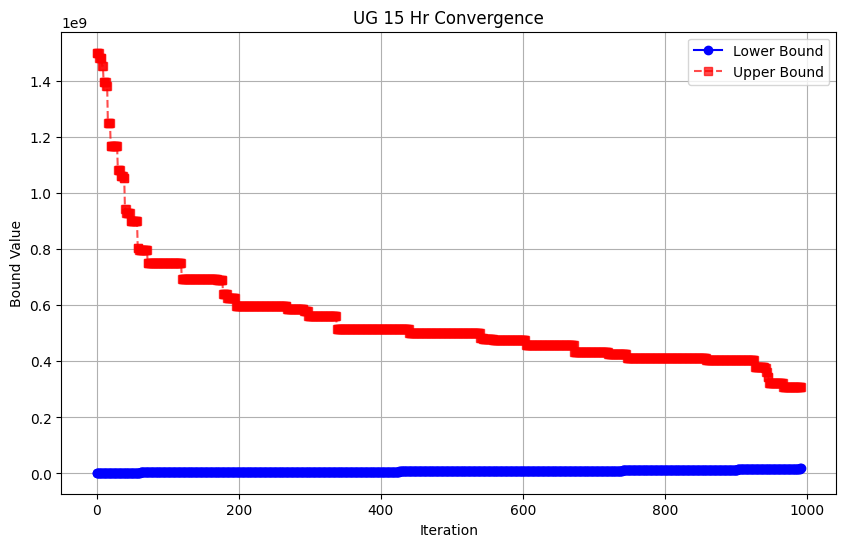

In [5]:
import matplotlib.pyplot as plt

# # Adjust the length of both lists to match the shorter one
# min_length = min(len(lower_bounds), len(upper_bounds))

# # Trim both lists to the same length
# lower_bounds = lower_bounds[:min_length]
# upper_bounds = upper_bounds[:min_length]
# iterations = list(range(min_length))

# Plot the adjusted lower and upper bounds
plt.figure(figsize=(10, 6))
# Plot lower and upper bounds
plt.plot(new_updated_data["lb"], label="Lower Bound", marker="o", linestyle="-", color="blue")
plt.plot(new_updated_data["ub"], label="Upper Bound", marker="s", linestyle="--", color="red", alpha=0.7)

# Labels and title
plt.xlabel("Iteration")
plt.ylabel("Bound Value")
plt.title("UG 15 Hr Convergence")
plt.legend()
plt.grid(True)
# plt.savefig("UG_HPC_15hr_convergence.pdf")
# Show the plot
plt.show()
